# Import Necessery Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Better looking plots
plt.style.use('seaborn-v0_8')

pd.set_option('display.float_format', '{:.2f}'.format)

# Read & inspect data

In [2]:
df = pd.read_csv("fuel_efficiency_dataset.csv")

print("Shape", df.shape)
print("\nMissing Value:")
print(df.isnull().sum())

display(df.head())
display(df.describe())

Shape (1000, 18)

Missing Value:
vehicle_id           0
engine_cc            0
cylinders            0
weight_kg            0
horsepower           0
torque_nm            0
vehicle_age          0
num_gears            0
tire_size_inch       0
aerodrag_coeff       0
ac_installed         0
mileage_km           0
fuel_type            0
drive_type           0
vehicle_class        0
turbo                0
service_history    335
mpg                  0
dtype: int64


,vehicle_id,engine_cc,cylinders,weight_kg,horsepower,torque_nm,vehicle_age,num_gears,tire_size_inch,aerodrag_coeff,ac_installed,mileage_km,fuel_type,drive_type,vehicle_class,turbo,service_history,mpg
0,V0001,4256,6,2099,688,374,5,4,22,0.46,1,13314,Diesel,AWD,Van,0,Full,16.60
1,V0002,1122,3,1438,374,461,20,5,20,0.51,0,170906,Diesel,RWD,Compact,0,Partial,61.72
2,V0003,1367,4,822,391,428,15,8,20,0.30,0,148850,Gasoline,RWD,Sports,1,Partial,52.45
3,V0004,5853,8,2380,660,714,22,7,18,0.52,1,153442,Electric,RWD,Truck,0,NaN,19.19
4,V0005,4185,4,3859,66,212,11,4,19,0.32,0,284879,Diesel,AWD,SUV,0,Full,22.52


,engine_cc,cylinders,weight_kg,horsepower,torque_nm,vehicle_age,num_gears,tire_size_inch,aerodrag_coeff,ac_installed,mileage_km,turbo,mpg
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,3667.67,7.24,2356.18,379.33,478.11,12.71,6.85,18.14,0.40,0.47,148086.07,0.52,40.24
std,1643.18,3.17,918.81,189.24,237.44,7.63,2.01,2.22,0.09,0.50,88279.25,0.50,20.30
min,805.00,3.00,804.00,60.00,81.00,0.00,4.00,15.00,0.25,0.00,503.00,0.00,5.00
25%,2252.75,4.00,1541.00,215.00,273.00,6.00,5.00,16.00,0.33,0.00,71077.25,0.00,25.60
50%,3633.00,8.00,2364.00,377.00,478.50,13.00,7.00,18.00,0.40,0.00,151656.50,1.00,36.74
75%,5119.25,10.00,3134.00,541.25,684.25,19.00,9.00,20.00,0.48,1.00,225311.75,1.00,49.59
max,6494.00,12.00,4000.00,700.00,899.00,25.00,10.00,22.00,0.55,1.00,299414.00,1.00,127.63


# Quick look at target distribution

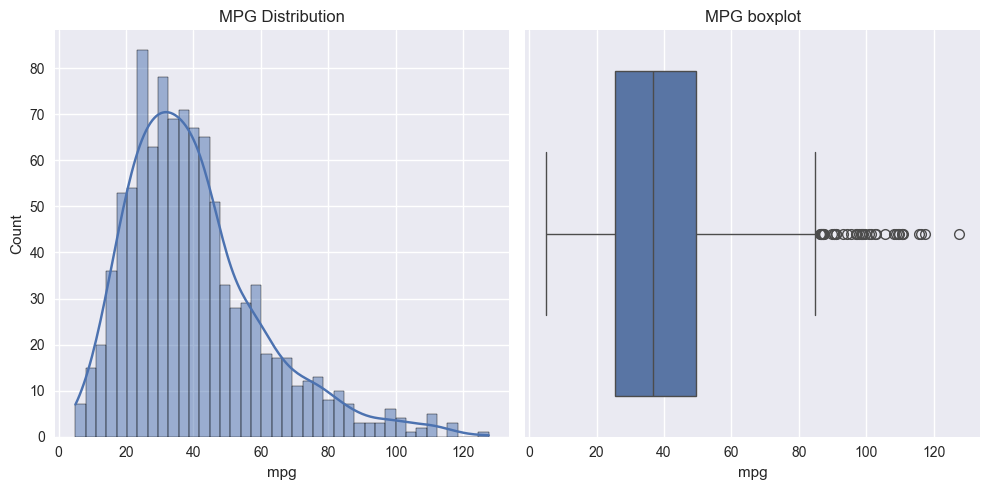

Negetive MPG Values:  0


In [3]:
target = df['mpg']

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(target, bins = 40, kde = True)
plt.title("MPG Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=target)
plt.title("MPG boxplot")

plt.tight_layout()
plt.show()

print("Negetive MPG Values: ", (target<0).sum())

# Detect outliers (using IQR method) for all numeric columns

In [4]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric columns: {numeric_cols}\n")

# Function to find outliers using IQR
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return outliers, lower_bound, upper_bound

# Dictionary to store results
outlier_summary = {}

print("Outlier detection using IQR method (1.5 × IQR):\n" + "-"*60)

for col in numeric_cols:
    outliers, lb, ub = find_outliers_iqr(df, col)
    outlier_summary[col] = {
        'count': len(outliers),
        'percentage': len(outliers)/len(df)*100,
        'min_outlier': outliers.min() if not outliers.empty else np.nan,
        'max_outlier': outliers.max() if not outliers.empty else np.nan,
        'lower_bound': lb,
        'upper_bound': ub
    }
    
    if len(outliers) > 0:
        print(f"{col:20} → {len(outliers):3d} outliers ({len(outliers)/len(df)*100:.2f}%)")
        print(f"   Range: [{lb:.2f}, {ub:.2f}]")
        print(f"   Extreme values: min={outliers.min():.2f}, max={outliers.max():.2f}")
        print()

# Summary table
summary_df = pd.DataFrame(outlier_summary).T
summary_df = summary_df.round(2)
print("\nOutlier Summary Table:")
display(summary_df)

Numeric columns: ['engine_cc', 'cylinders', 'weight_kg', 'horsepower', 'torque_nm', 'vehicle_age', 'num_gears', 'tire_size_inch', 'aerodrag_coeff', 'ac_installed', 'mileage_km', 'turbo', 'mpg']

Outlier detection using IQR method (1.5 × IQR):
------------------------------------------------------------
mpg                  →  38 outliers (3.80%)
   Range: [-10.39, 85.58]
   Extreme values: min=86.19, max=127.63


Outlier Summary Table:


,count,percentage,min_outlier,max_outlier,lower_bound,upper_bound
engine_cc,0.00,0.00,NaN,NaN,-2047.00,9419.00
cylinders,0.00,0.00,NaN,NaN,-5.00,19.00
weight_kg,0.00,0.00,NaN,NaN,-848.50,5523.50
horsepower,0.00,0.00,NaN,NaN,-274.38,1030.62
torque_nm,0.00,0.00,NaN,NaN,-343.88,1301.12
vehicle_age,0.00,0.00,NaN,NaN,-13.50,38.50
num_gears,0.00,0.00,NaN,NaN,-1.00,15.00
tire_size_inch,0.00,0.00,NaN,NaN,10.00,26.00
aerodrag_coeff,0.00,0.00,NaN,NaN,0.09,0.72
ac_installed,0.00,0.00,NaN,NaN,-1.50,2.50


# Cap outliers (winsorization)

In [5]:
# Option B: Cap (winsorize) outliers instead of removing rows
# → values below lower bound → lower bound
# → values above upper bound → upper bound

df_capped = df.copy()

for col in numeric_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Cap the values
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

print("Outliers have been capped (winsorized).")
print("Original vs capped summary for yield_kg_per_ha:")
print(pd.concat([
    df['mpg'].describe(),
    df_capped['mpg'].describe()
], axis=1, keys=['Original', 'Capped']).round(0))

Outliers have been capped (winsorized).
Original vs capped summary for yield_kg_per_ha:
       Original  Capped
count   1000.00 1000.00
mean      40.00   40.00
std       20.00   19.00
min        5.00    5.00
25%       26.00   26.00
50%       37.00   37.00
75%       50.00   50.00
max      128.00   86.00


# Compare boxplots before & after capping

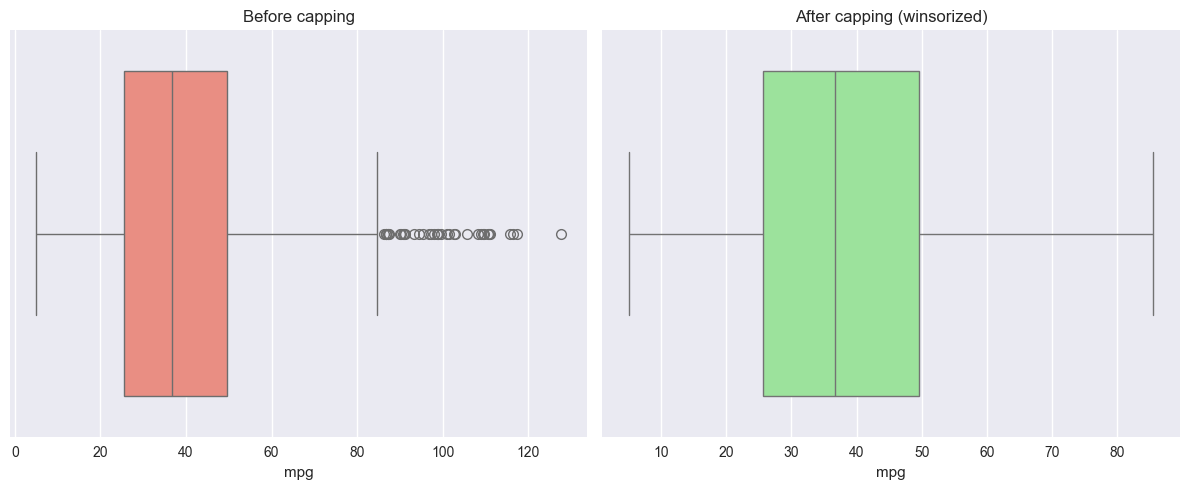

In [6]:
# Visual comparison before vs after capping (only for house_price_usd as example)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

sns.boxplot(x=df['mpg'], color='salmon')
plt.title("Before capping")
plt.xlabel("mpg")

plt.subplot(1, 2, 2)
sns.boxplot(x=df_capped['mpg'], color='lightgreen')
plt.title("After capping (winsorized)")
plt.xlabel("mpg")

plt.tight_layout()
plt.show()

# Prepare features and target

In [7]:
# Features and target
y = target
x = df.drop('mpg', axis = 1)

# We'll keep negative MPG values (they seem intentional in this synthetic dataset)

# Define categorical and numerical columns

In [14]:
 # all category accept target
features = df.drop(columns=['mpg', 'vehicle_id'])

# define numeric features
numeric_features = features.select_dtypes(include=['number', 'float', 'int64']).columns.tolist()

# define categorical features
categorical_features = features.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric Features: ", numeric_features)
print("Categorical Features: ", categorical_features)

Numeric Features:  ['engine_cc', 'cylinders', 'weight_kg', 'horsepower', 'torque_nm', 'vehicle_age', 'num_gears', 'tire_size_inch', 'aerodrag_coeff', 'ac_installed', 'mileage_km', 'turbo']
Categorical Features:  ['fuel_type', 'drive_type', 'vehicle_class', 'service_history']


# Create preprocessor + polynomial pipeline

In [15]:
degree = 2

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

model = Pipeline([
    ('prepocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=degree, include_bias= False)),
    ('regressor', LinearRegression())
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prepocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

# Train / test split

In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size = 0.2,
    random_state = 42
)

print(f"Train: {x_train.shape[0]} rows")
print(f" Test: {x_test.shape[0]} rows")

Train: 800 rows
 Test: 200 rows


# Train the model

In [17]:
%%time
model.fit(x_train, y_train)

print("Model Trained")

Model Trained
CPU times: total: 109 ms
Wall time: 51.7 ms


# Predictions & evaluation function

In [18]:
y_pred_train = model.predict(x_train)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("┌────────────────────── TRAIN ──────────────────────┐")
print(f"│ MAE  = {mae_train:10.3f}                                 │")
print(f"│ RMSE = {rmse_train:10.3f}                                 │")
print(f"│ R²   = {r2_train:10.3f}                                 │")
print("└───────────────────────────────────────────────────┘")

y_pred_test = model.predict(x_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("┌────────────────────── TEST ───────────────────────┐")
print(f"│ MAE  = {mae_test:10.3f}                                 │")
print(f"│ RMSE = {rmse_test:10.3f}                                 │")
print(f"│ R²   = {r2_test:10.3f}                                 │")
print("└───────────────────────────────────────────────────┘")

┌────────────────────── TRAIN ──────────────────────┐
│ MAE  =      1.336                                 │
│ RMSE =      1.686                                 │
│ R²   =      0.993                                 │
└───────────────────────────────────────────────────┘
┌────────────────────── TEST ───────────────────────┐
│ MAE  =      2.196                                 │
│ RMSE =      2.785                                 │
│ R²   =      0.983                                 │
└───────────────────────────────────────────────────┘


# Visual comparison (actual vs predicted)

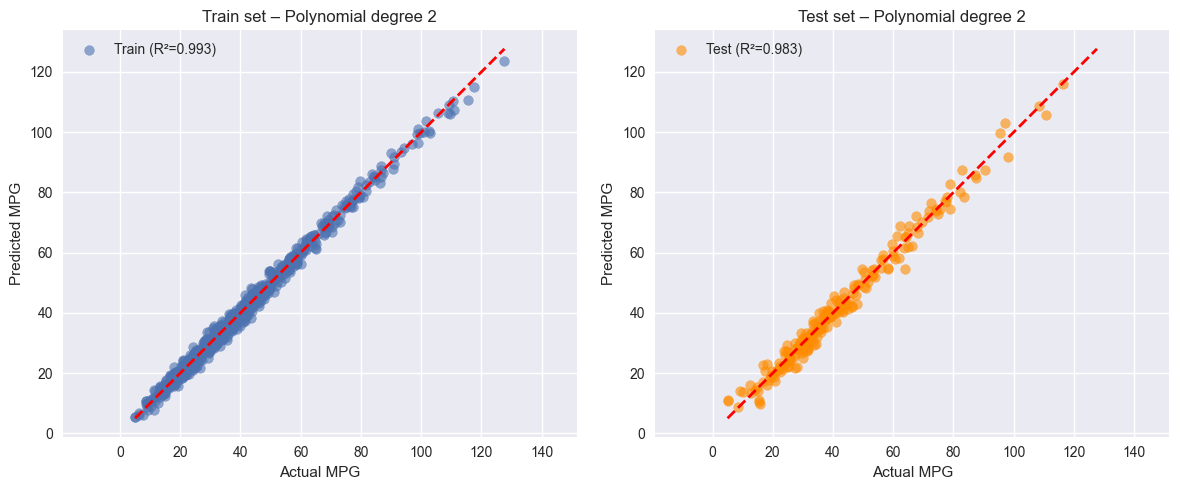

In [19]:
plt.figure(figsize=(12, 5))

# Train
plt.subplot(1,2,1)
plt.scatter(y_train, y_pred_train, alpha=0.6, 
            label=f'Train (R²={r2_score(y_train, y_pred_train):.3f})')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title(f"Train set – Polynomial degree {degree}")
plt.legend()
plt.axis('equal')

# Test
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_test, alpha=0.6, color='darkorange', 
            label=f'Test (R²={r2_score(y_test, y_pred_test):.3f})')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title(f"Test set – Polynomial degree {degree}")
plt.legend()
plt.axis('equal')

plt.tight_layout()
plt.show()

# Try different degrees – comparison

In [20]:
results = []

for deg in [1, 2, 3, 4]:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('model', LinearRegression())
    ])
    
    pipe.fit(x_train, y_train)
    
    # Predictions
    y_pred_train = pipe.predict(x_train)
    y_pred_test  = pipe.predict(x_test)
    
    # Metrics
    r2_train   = r2_score(y_train, y_pred_train)
    r2_test    = r2_score(y_test,  y_pred_test)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
    
    results.append({
        'degree':     deg,
        'R² train':   r2_train,
        'R² test':    r2_test,
        'R² diff':    r2_train - r2_test,
        'RMSE train': rmse_train,
        'RMSE test':  rmse_test,
        'RMSE diff':  rmse_train - rmse_test   # positive = worse on train (rare), negative = overfitting
    })

# Create DataFrame and style it
df_results = pd.DataFrame(results).round(4)

# Optional: highlight best test performance
styled = df_results.style\
    .background_gradient(subset=['R² test'], cmap='RdYlGn')\
    .background_gradient(subset=['RMSE test'], cmap='YlOrRd_r')\
    .format({
        'R² train':   '{:.4f}',
        'R² test':    '{:.4f}',
        'R² diff':    '{:+.4f}',
        'RMSE train': '{:.4f}',
        'RMSE test':  '{:.4f}',
        'RMSE diff':  '{:+.4f}'
    })\
    .highlight_max(subset=['R² test'], color='#dedda')\
    .highlight_min(subset=['RMSE test'], color='#dedda')

print("Model comparison across polynomial degrees:")
display(styled)

Model comparison across polynomial degrees:


,degree,R² train,R² test,R² diff,RMSE train,RMSE test,RMSE diff
0,1,0.9135,0.9246,-0.0112,5.8742,5.8634,+0.0108
1,2,0.9929,0.9830,+0.0099,1.6858,2.7849,-1.0991
2,3,1.0000,0.8719,+0.1281,0.0000,7.6426,-7.6426
3,4,1.0000,0.8198,+0.1802,0.0000,9.0670,-9.0670


# FINAL MODEL WITH BEST DEGREE + VISUALIZATION

Final model (degree 2) performance on test set:
• R²   = 0.9830
• RMSE = $3
• MAE  = $2



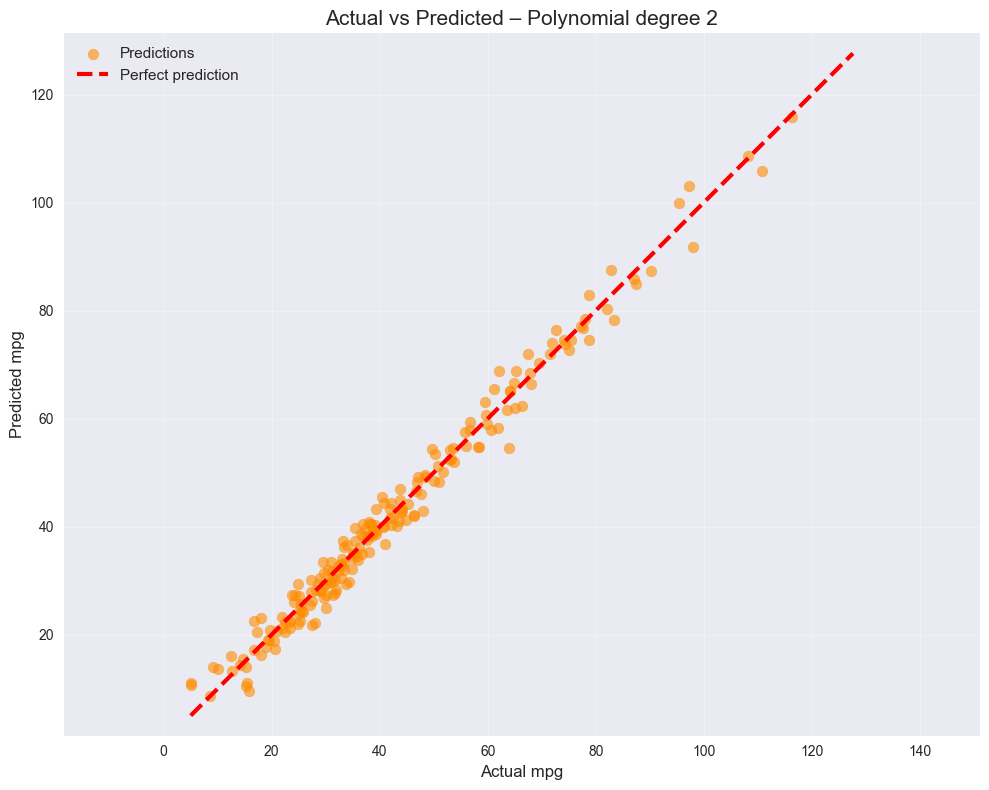

In [24]:
best_degree = df_results.loc[df_results['R² test'].idxmax(), 'degree']

final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly',         PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('model',        LinearRegression())
])

final_pipe.fit(x_train, y_train)

y_pred_test = final_pipe.predict(x_test)

mae   = mean_absolute_error(y_test, y_pred_test)
rmse  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2    = r2_score(y_test, y_pred_test)

print(f"Final model (degree {best_degree}) performance on test set:")
print(f"• R²   = {r2:.4f}")
print(f"• RMSE = ${rmse:,.0f}")
print(f"• MAE  = ${mae:,.0f}\n")

# Actual vs Predicted
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, s=60, color='darkorange', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3, label='Perfect prediction')
plt.xlabel("Actual mpg", fontsize=12)
plt.ylabel("Predicted mpg", fontsize=12)
plt.title(f"Actual vs Predicted – Polynomial degree {best_degree}", fontsize=15)
plt.legend(fontsize=11)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# EXAMPLE PREDICTION

In [25]:
# =============================================================================
#          PREDICTION EXAMPLE - NEW CAR FUEL EFFICIENCY (MPG)
# =============================================================================

# Create a single-row DataFrame with ONE realistic example vehicle
new_car = pd.DataFrame([{
    'engine_cc': 1998,
    'cylinders': 4,
    'weight_kg': 1480,
    'horsepower': 158,
    'torque_nm': 240,
    'vehicle_age': 3,
    'num_gears': 6,
    'tire_size_inch': 18,
    'aerodrag_coeff': 0.32,
    'ac_installed': 1,               # 1 = Yes, 0 = No
    'mileage_km': 14500,             # annual mileage
    'fuel_type': 'Gasoline',
    'drive_type': 'FWD',
    'vehicle_class': 'Sedan',
    'turbo': 1,                      # 1 = Yes, 0 = No
    'service_history': 'Full'        # 'Full', 'Partial', or NaN / 'None'
    # Note: vehicle_id is not used in modeling → we don't need to include it
}])

# ─── Important notes ───────────────────────────────────────────────
# 1. Column names must match exactly what was used during training
# 2. Categorical columns must contain strings (just like in the original data)
# 3. Missing columns → pipeline may fail → make sure all features are present

# Predict using your final trained pipeline
# (replace 'final_pipe' with your actual pipeline variable name if different)
try:
    predicted_mpg = final_pipe.predict(new_car)[0]
    print(f"Predicted fuel efficiency (MPG): {predicted_mpg:.2f}")
except Exception as e:
    print("Prediction failed. Error message:")
    print(str(e))
    print("\nCommon reasons:")
    print("• final_pipe not fitted yet (run training cell first)")
    print("• Column names or order don't match training data")
    print("• Missing required columns in new_car DataFrame")
    print("• Unknown category in one of the categorical fields")

Predicted fuel efficiency (MPG): 69.61
